# Problem Definition:
In this assignment, we want to tackle a real-world optimization problem in wireless sensor networks. Hundreds of wireless sensors collect and transmit environmental data to base stations (BS) in Beaulieu and Lyndhurst. Each sensor must establish an efficient routing path to a base station while balancing two objectives:
1. Maximizing the end-to-end data transmission rate (minimum rate along the path).
2. Minimizing the end-to-end latency (sum of delays across all links in the path).


##Constraints
These objectives are subject to the constraints listed below:

* Communication between nodes is limited by distance thresholds (e.g., no communication if the distance exceeds 3000 m).
* Routing paths must end at one of the two base stations.



Mathematically, the problem is stated as a multi-objective optimization task:
1.   Minimize 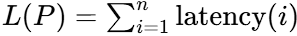
2.   Maximize 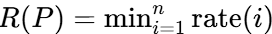, where P is a routing path

This sort of multi-objective optimization problem has been widely studied, with techniques such as Dijkstra's algorithm and metaheuristic approaches like Genetic Algorithms frequently used to find optimal or near-optimal solutions.

In environmental monitoring scenarios, such as those in the New Forest, England, efficient data routing ensures reliable transmission with minimal energy consumption and delay. These optimizations are particularly relevant for large-scale WSNs, where improper routing can lead to bottlenecks, data loss, or inefficient use of resources (Tilak et al., 2002).

##Project scope
This project solves the routing problem using three optimization algorithms: Dijkstra's algorithm, Ant Colony Optimization (ACO), and Genetic Algorithm (GA). The results of these methods are analyzed and compared to determine their effectiveness in terms of latency and transmission rate.

#Methodology
This project solves the routing path optimization problem using three optimization methods: Dijkstra's Algorithm, Genetic Algorithm (GA), and Ant Colony Optimization (ACO). These algorithms are written in Python and use important libraries like numpy, pandas, scipy, and heapq to perform matrix operations, distance calculations, and priority queue management. The approach includes dataset preparation, implementation details, and evaluation criteria.

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import json
from scipy.spatial import distance
import random

In [ ]:
#Reading the dataset
data = pd.read_csv('sub_data_file_with_header.csv')
data["x"] = pd.to_numeric(data["x"], errors="coerce")
data["y"] = pd.to_numeric(data["y"], errors="coerce")


In [ ]:
#Checking dataset values
data.head()

,No.,x,y
0,1,4873.6,4886.7
1,2,-3295.7,-4330.5
2,3,-2407.1,4397.4
3,4,-1027.0,-4828.9
4,5,-4260.1,1838.4


In [ ]:
data.tail()

,No.,x,y
145,146,4855.50,3370.30
146,147,-4696.20,-3601.40
147,148,356.64,882.09
148,149,-4119.90,-1327.30
149,150,3020.90,3067.60


##Data preparation

The base stations are appended to the dataset to ensure that they may be used as endpoints for routing paths.

We'll add these base stations to the dataset using the information provided in the submission brief. The two base stations provided are as follows:
* Beaulieu (5000,- 5000), and
* Lyndhurst (-5000, 5000)

In [ ]:
# Adding base stations
base_data = pd.DataFrame({"No.": [151, 152], "x": [-5000, 5000], "y": [5000, -5000]})
data = pd.concat([data, base_data], ignore_index=True)
coordinates = data[["x", "y"]].values

In [ ]:
#Checking if the base stations are added successfuly
data.tail()

,No.,x,y
147,148,356.64,882.09
148,149,-4119.90,-1327.30
149,150,3020.90,3067.60
150,151,-5000.00,5000.00
151,152,5000.00,-5000.00


Now that the dataset includes wireless sensor node coordinates and two base station locations, the next preprocessing steps include:
* **Creating a distance Matrix:** Calculated using the Euclidean distance formula:
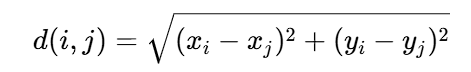(Deza and Deza, 2014)
and
* **Adding a rate Matrix:** Derived based on the assignment's transmission rate thresholds:
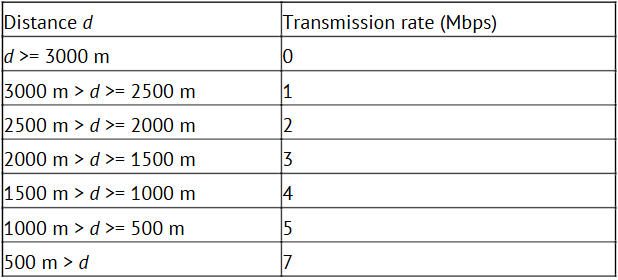



Latency per link is set as a constant of 30 ms for the entirety of this project. However, it can be made more accurate to real world conditions by using ranom() function to insert some noise.

In [ ]:
num_nodes = len(coordinates)
distance_matrix = distance.cdist(coordinates, coordinates, 'euclidean')
rate_matrix = np.zeros_like(distance_matrix)
LATENCY_PER_LINK = 30

In [ ]:
print("Sample Distances Between Nodes:")
for i in range(5):
    for j in range(5):
        if i != j:
            print(f"Distance between Node-{i + 1} and Node-{j + 1}: {distance_matrix[i, j]:.2f} meters")


Sample Distances Between Nodes:
Distance between Node-1 and Node-2: 12316.42 meters
Distance between Node-1 and Node-3: 7297.12 meters
Distance between Node-1 and Node-4: 11367.06 meters
Distance between Node-1 and Node-5: 9628.95 meters
Distance between Node-2 and Node-1: 12316.42 meters
Distance between Node-2 and Node-3: 8773.02 meters
Distance between Node-2 and Node-4: 2322.80 meters
Distance between Node-2 and Node-5: 6243.83 meters
Distance between Node-3 and Node-1: 7297.12 meters
Distance between Node-3 and Node-2: 8773.02 meters
Distance between Node-3 and Node-4: 9328.95 meters
Distance between Node-3 and Node-5: 3159.44 meters
Distance between Node-4 and Node-1: 11367.06 meters
Distance between Node-4 and Node-2: 2322.80 meters
Distance between Node-4 and Node-3: 9328.95 meters
Distance between Node-4 and Node-5: 7409.85 meters
Distance between Node-5 and Node-1: 9628.95 meters
Distance between Node-5 and Node-2: 6243.83 meters
Distance between Node-5 and Node-3: 3159.44 me

 Step 1: Calculate distance and rate matrices

 Python libraries such as numpy and scipy are used to efficiently compute the distance matrix (Harris et al., 2020).

In [ ]:
# Compute distance matrix
def calculate_distance_matrix(coords):
    num_nodes = coords.shape[0]
    dist_matrix = np.zeros((num_nodes, num_nodes))
    for i in range(num_nodes):
        for j in range(num_nodes):
            dist_matrix[i, j] = np.linalg.norm(coords[i] - coords[j])
    return dist_matrix

distance_matrix = calculate_distance_matrix(coordinates)

In [ ]:
# Transmission rates based on distance
def calculate_transmission_rate(distance):
    if distance >= 3000:
        return 0
    elif 3000 > distance >= 2500:
        return 1
    elif 2500 > distance >= 2000:
        return 2
    elif 2000 > distance >= 1500:
        return 3
    elif 1500 > distance >= 1000:
        return 4
    elif 1000 > distance >= 500:
        return 5
    else:
        return 7

# Transmission rate matrix
rate_matrix = np.vectorize(calculate_transmission_rate)(distance_matrix)

In [ ]:
base_station_indices = list(range(len(distance_matrix) - 2, len(distance_matrix)))

In [63]:
base_stations = [len(data) - 2, len(data) - 1]
print("Base Station Coordinates:")
print(data.iloc[base_stations])

Base Station Coordinates:
     No.       x       y
150  151 -5000.0  5000.0
151  152  5000.0 -5000.0


These matrices serve as inputs for the optimization algorithms.


In [ ]:
# Latency calculation (fixed latency per link)
def calculate_latency(path):
    return (len(path)-1) * 30  # 30 ms per link

# Dijkastra algorithm
Edsger W. Dijkstra proposed the Dijkstra algorithm, a fundamental network traversal technique, in 1959. It is commonly used to find the shortest path between nodes in a graph, with edge weights representing costs such as distance, time, or latencies (Dijkstra, 1959). It systematically selects the path with the lowest cost in terms of distance or another metric (Wahyuningsih and Syahreza 2018).



In the context of wireless sensor networks (WSNs), the problem of optimizing routing paths is well-suited to Dijkstra's method. Each node (wireless sensor) aims to provide data to a base station while minimizing total latency along the routing path. Latency is calculated as the total of delays across each communication link, which are represented by edge weights in the graph. Dijkstra's method is an excellent candidate for minimizing this objective since it ensures the shortest latency path for each node to a base station (Tilak et al., 2002).

The assignment must tackle addressing the latency minimization while ensuring connectivity constraints are met. Dijkstra's method effectively handles the following requirements:

* **Deterministic optimization:** This ensures the shortest path to a base station, establishing a clear baseline for comparing different methods such as heuristic algorithms.

* **Scalability:** With a polynomial-time complexity of O(V^2) for dense graphs and 𝑂(𝐸 + 𝑉 log𝑉) for sparse graphs with a priority queue, it is suitable for medium to large sensor networks as it offers scalability (Cormen et al., 2009).

* **Relevance to Network Optimization:** Applications in routing and navigation support its suitability for this task (Akyildiz et al., 2002).

By including Dijkstra's algorithm into the solution, the study utilizes its efficiency and optimality, providing a standard for evaluating more complicated methods like GAs and ACOs.

The function **create_graph_** converts the graph into an adjacency list:

**Initialization:** Each node is assigned an empty list to record its neighbors and their latencies.

**Edge construction:** For every pair of nodes i and j:
If i≠j and the transmission rate is larger than 0, the latency is calculated and added to node i's adjacency list.

**Output:** The function provides a dictionary with keys representing nodes and values containing lists of tuples identifying neighbors and their latencies.
The base stations are explicitly set up as the dataset's last two nodes, making them accessible for routing paths.


##Execute Dijkastra's algorithm

In [ ]:
def reconstruct_path(path, start_node, end_node):
    current_node = end_node
    route = []
    while current_node != -1:
        route.append(current_node)
        current_node = path[current_node]
    return route[::-1]

In [ ]:
def dijkstra(start_node, distance_matrix, rate_matrix, base_station_indices):
    num_nodes = distance_matrix.shape[0]
    visited = [False] * num_nodes
    dist = [float('inf')] * num_nodes
    dist[start_node] = 0
    path = [-1] * num_nodes

    for _ in range(num_nodes):
        min_dist = float('inf')
        min_index = -1

        # Find the unvisited node with the smallest distance
        for i in range(num_nodes):
            if not visited[i] and dist[i] < min_dist:
                min_dist = dist[i]
                min_index = i

        # Mark the selected node as visited
        visited[min_index] = True

        # Update distances to neighboring nodes
        for j in range(num_nodes):
            if distance_matrix[min_index, j] > 0 and rate_matrix[min_index, j] > 0 and not visited[j]:
                new_dist = dist[min_index] + distance_matrix[min_index, j]
                if new_dist < dist[j]:
                    dist[j] = new_dist
                    path[j] = min_index

    # Find the nearest base station
    best_base_station = min(base_station_indices, key=lambda bs: dist[bs])
    optimal_path = reconstruct_path(path, start_node, best_base_station)

    # Calculate metrics
    total_latency = calculate_latency(optimal_path)
    end_to_end_rate = min(
        rate_matrix[optimal_path[i], optimal_path[i + 1]] for i in range(len(optimal_path) - 1)
    )

    # Format results for output
    routing_path = []
    for i in range(len(optimal_path) - 1):
        current_node = optimal_path[i]
        next_node = optimal_path[i + 1]
        transmission_rate = rate_matrix[current_node, next_node]
        routing_path.append(f"(Node-{next_node}, {transmission_rate} Mbps)")

    result = {
        "Source node": f"Node-{start_node}",
        "routing path": ", ".join(routing_path),
        "End-to-end transmission rate": f"{end_to_end_rate} Mbps"
    }

    return result, path

The generate_routing_paths_dijkstra function iterates over all sensor nodes as source nodes, then uses the Dijkstra algorithm to generate paths.

For every source node: The routing path is documented as a list of nodes and their respective transmission rates.

The end-to-end transmission rate is calculated as the lowest transmission rate along the path.
If no valid path is found, a failure message is stored for that node.


##Dijkastra's output

In [ ]:
def visualize_optimal_path(optimal_path, coordinates):
    G = nx.Graph()

    # Add nodes
    for i, coord in enumerate(coordinates):
        G.add_node(i, pos=(coord[0], coord[1]))

    # Add edges in the optimal path
    edges = [(optimal_path[i], optimal_path[i + 1]) for i in range(len(optimal_path) - 1)]
    G.add_edges_from(edges)

    # Plot the graph
    pos = nx.get_node_attributes(G, 'pos')
    plt.figure(figsize=(10, 10))
    nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='red', width=2)
    plt.title("Optimal Path Visualization")
    plt.show()

In [ ]:
start_node = 0  # Example source node
results, path_array = dijkstra(start_node, distance_matrix, rate_matrix, base_station_indices)
print(json.dumps(results, indent=4))

{
    "Source node": "Node-0",
    "routing path": "(Node-145, 3 Mbps), (Node-35, 1 Mbps), (Node-117, 2 Mbps), (Node-96, 2 Mbps), (Node-151, 4 Mbps)",
    "End-to-end transmission rate": "1 Mbps"
}


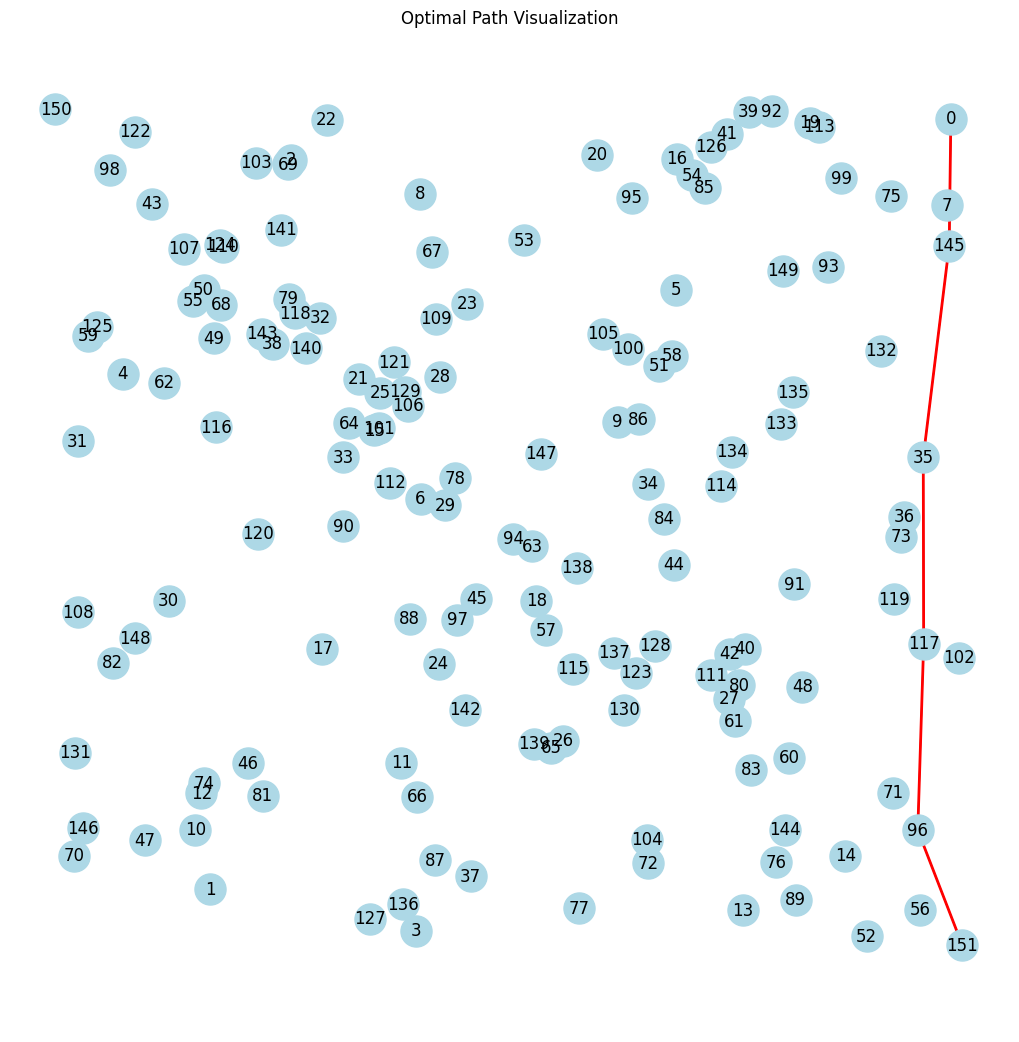

In [ ]:
# Visualize the optimal path
optimal_path = reconstruct_path(
    path=path_array,
    start_node=start_node,
    end_node=base_station_indices[1]  # Replace with the actual nearest base station
)
visualize_optimal_path(optimal_path, coordinates)

In [ ]:
all_results = {}
for node in range(len(distance_matrix) - len(base_station_indices)):
    all_results[f"Node-{node}"], path_array = dijkstra(node, distance_matrix, rate_matrix, base_station_indices)

# Save the results to a JSON file
output_file = "dijkstra_results.json"
with open(output_file, "w") as f:
    json.dump(all_results, f, indent=4)

print(f"All results have been saved to {output_file}")

All results have been saved to dijkstra_results.json


All paths are saved in a JSON file (dijkstra_routing_paths.json) for future analysis and validation.

In [ ]:
with open("dijkstra_results.json", "r") as file:
    routing_paths = json.load(file)

print(json.dumps(routing_paths, indent=4))

{
    "Node-0": {
        "Source node": "Node-0",
        "routing path": "(Node-145, 3 Mbps), (Node-35, 1 Mbps), (Node-117, 2 Mbps), (Node-96, 2 Mbps), (Node-151, 4 Mbps)",
        "End-to-end transmission rate": "1 Mbps"
    },
    "Node-1": {
        "Source node": "Node-1",
        "routing path": "(Node-136, 2 Mbps), (Node-77, 3 Mbps), (Node-13, 3 Mbps), (Node-151, 2 Mbps)",
        "End-to-end transmission rate": "2 Mbps"
    },
    "Node-2": {
        "Source node": "Node-2",
        "routing path": "(Node-150, 1 Mbps)",
        "End-to-end transmission rate": "1 Mbps"
    },
    "Node-3": {
        "Source node": "Node-3",
        "routing path": "(Node-77, 3 Mbps), (Node-13, 3 Mbps), (Node-151, 2 Mbps)",
        "End-to-end transmission rate": "2 Mbps"
    },
    "Node-4": {
        "Source node": "Node-4",
        "routing path": "(Node-125, 5 Mbps), (Node-150, 1 Mbps)",
        "End-to-end transmission rate": "1 Mbps"
    },
    "Node-5": {
        "Source node": "Node-5",


**Key Features of Implementation**

* **Efficient Graph Traversal:** The priority queue optimizes node exploration and minimizes latency.
* **Transmission Rate Tracking:** We record each hop's transmission rate and calculate the minimal rate to meet the problem objectives.
*Results are serialized into a structured JSON file for easy storage and examination of best pathways.


# Ant Colony Optimization:

Ant Colony Optimization (ACO) is a bio-inspired metaheuristic algorithm that simulates ant foraging behavior. Proposed by Dorigo et al. (1991), it is commonly used to solve discrete optimization problems such as routing in WSNs. ACO's strength is its ability to explore many different paths at the same time while balancing exploration and exploitation using pheromone trails and heuristic factors (Blum, 2005).

ACO is used to optimize the routing patterns between sensor nodes and base stations. It adjusts parameters like pheromone evaporation rate (ρ) and heuristic importance (β) to optimize latency and transmission rate within the network constraints (Li and Liu, 2012).

## Initialize parameters

Each ant represents a potential solution and starts its journey at a source node. The graph is initialized with:
* Pheromone Levels (τij): Each edge begins with a uniform pheromone value (τinitial) that is updated iteratively.
* Heuristic information (ηij): Defined as the inverse of the distance between nodes i and j, ants are encouraged to prioritize shorter edges, and calculated as: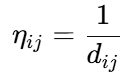

Parameters such as the number of ants, iterations, and the relative influence of pheromone (α) and heuristic (β) factors are fine-tuned for efficient performance (Socha and Dorigo, 2008).

Ants use probabilistic path construction, picking the next node based on pheromone levels and heuristic values (Blum, 2005). The chance of traveling from node i to node j can be calculated as:

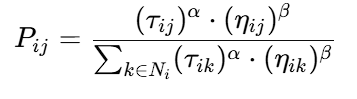

Where:
* Pij = probability of selecting node j from node i
* Tij =  pheromone lvel on the egdge ij
* nij = heuristic information
* α and β = weights controlling the influence of pheromone and heuristic information

## Update pheromones

After all ants have completed their paths, the pheromone levels at the edges are updated as follows:
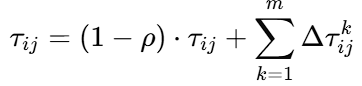

Where:
* ρ is the rate of pheromone evaporation to prevent over-concentration on one path.
* Δτij is the additional pheromone deposited by ants who chose edge ij.

This process balances between exploring new paths and reinforcing promising ones.

## Execute ACO

In [ ]:
def ant_colony_optimization(start_node, distance_matrix, rate_matrix, base_station_indices, num_ants=10, num_iterations=50):
    num_nodes = distance_matrix.shape[0]
    pheromone = np.ones((num_nodes, num_nodes))  # Initialize pheromone matrix
    best_path = None
    best_latency = float('inf')

    for _ in range(num_iterations):
        for ant in range(num_ants):
            path = [start_node]
            while path[-1] not in base_station_indices:
                current_node = path[-1]
                probabilities = []
                for neighbor in range(num_nodes):
                    if neighbor not in path and rate_matrix[current_node, neighbor] > 0:
                        probabilities.append(pheromone[current_node, neighbor] / distance_matrix[current_node, neighbor])
                    else:
                        probabilities.append(0)

                probabilities = np.array(probabilities, dtype=float)

                if probabilities.sum() == 0:  # Handle division by zero
                    # Randomly choose a valid neighbor if no probabilities exist
                    valid_neighbors = [
                        neighbor for neighbor in range(num_nodes)
                        if neighbor not in path and rate_matrix[current_node, neighbor] > 0
                    ]
                    if not valid_neighbors:
                        break  # Terminate this ant's path if no valid neighbors
                    next_node = np.random.choice(valid_neighbors)
                else:
                    probabilities /= probabilities.sum()  # Normalize probabilities
                    next_node = np.random.choice(range(num_nodes), p=probabilities)

                path.append(next_node)

            latency = calculate_latency(path)
            if latency < best_latency:
                best_latency = latency
                best_path = path

            # Update pheromones
            for i in range(len(path) - 1):
                pheromone[path[i], path[i + 1]] += 1.0 / latency

        # Evaporate pheromones
        pheromone *= 0.9

    # Calculate metrics for the best path
    end_to_end_rate = min(
        rate_matrix[best_path[i], best_path[i + 1]] for i in range(len(best_path) - 1)
    )

    routing_path = []
    for i in range(len(best_path) - 1):
        current_node = best_path[i]
        next_node = best_path[i + 1]
        transmission_rate = rate_matrix[current_node, next_node]
        routing_path.append(f"(Node-{next_node}, {transmission_rate} Mbps)")

    result = {
        "Source node": f"Node-{start_node}",
        "routing path": ", ".join(routing_path),
        "End-to-end transmission rate": f"{end_to_end_rate} Mbps"
    }

    return result, best_path

##ACO output

In [ ]:
start_node = 0  # Example source node
results, best_path = ant_colony_optimization(start_node, distance_matrix, rate_matrix, base_station_indices)  # Capture path array
print(json.dumps(results, indent=4))

{
    "Source node": "Node-0",
    "routing path": "(Node-99, 4 Mbps), (Node-132, 2 Mbps), (Node-119, 1 Mbps), (Node-111, 2 Mbps), (Node-13, 1 Mbps), (Node-60, 3 Mbps), (Node-56, 2 Mbps), (Node-151, 5 Mbps)",
    "End-to-end transmission rate": "1 Mbps"
}


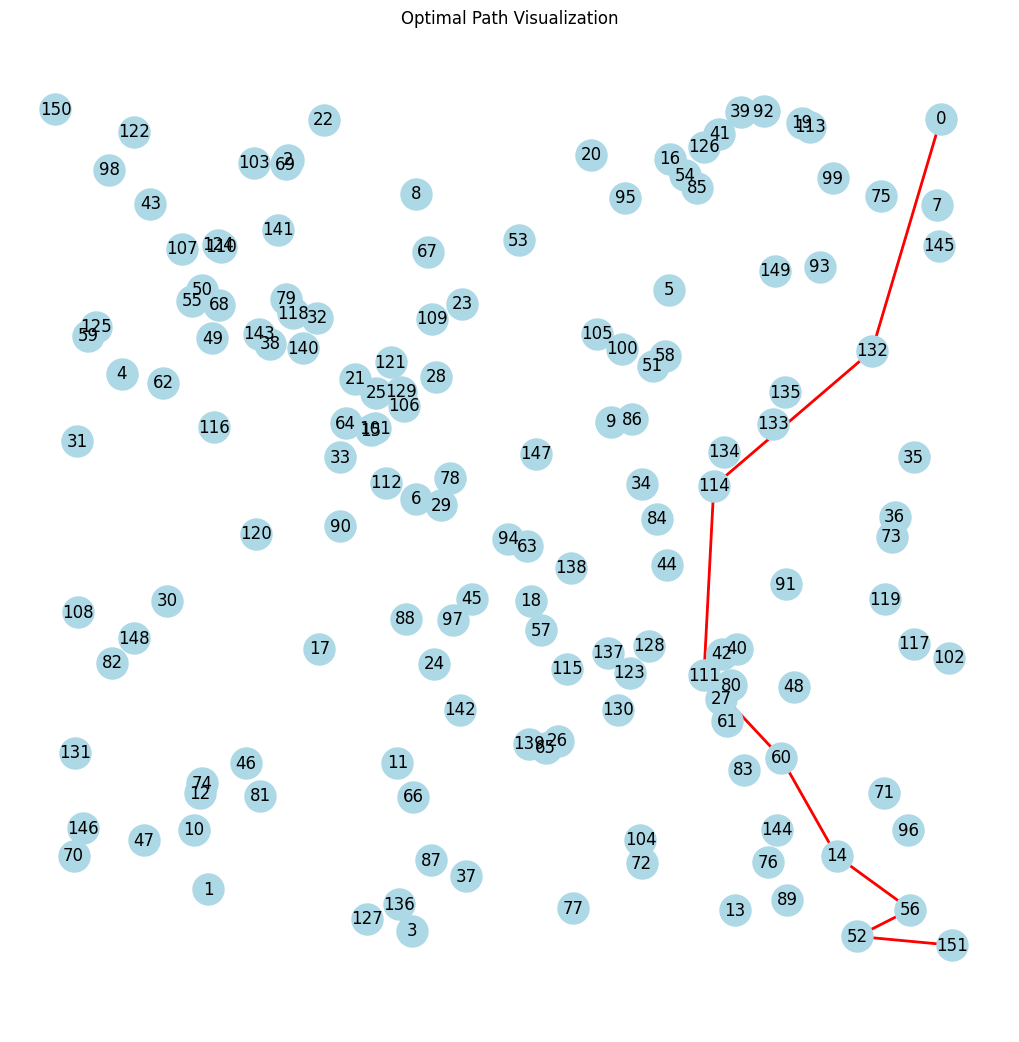

In [ ]:
# Visualize the optimal path
visualize_optimal_path(best_path, coordinates)

Even after reducing the number of iterations, number of ants, and fine tuning the parameters to speed up the process, the ant colony optimization takes a lot more time to execute when compared to dijkastra algorithm.

In [ ]:
# Run ACO for all nodes and save results to a JSON file
all_results_aco = {}
for node in range(len(distance_matrix) - len(base_station_indices)):
    results, _ = ant_colony_optimization(node, distance_matrix, rate_matrix, base_station_indices)
    all_results_aco[f"Node-{node}"] = results

In [ ]:
# Save the results to a JSON file
output_file = "aco_results.json"
with open(output_file, "w") as f:
    json.dump(all_results_aco, f, indent=4)

print(f"All ACO results have been saved to {output_file}")

All ACO results have been saved to aco_results.json


In [ ]:
with open("aco_results.json", "r") as file:
    routing_paths = json.load(file)

print(json.dumps(routing_paths, indent=4))

{
    "Node-0": {
        "Source node": "Node-0",
        "routing path": "(Node-113, 4 Mbps), (Node-19, 7 Mbps), (Node-99, 5 Mbps), (Node-93, 4 Mbps), (Node-135, 3 Mbps), (Node-134, 5 Mbps), (Node-80, 1 Mbps), (Node-57, 2 Mbps), (Node-128, 4 Mbps), (Node-104, 2 Mbps), (Node-96, 1 Mbps), (Node-151, 4 Mbps)",
        "End-to-end transmission rate": "1 Mbps"
    },
    "Node-1": {
        "Source node": "Node-1",
        "routing path": "(Node-70, 3 Mbps), (Node-108, 1 Mbps), (Node-31, 2 Mbps), (Node-55, 2 Mbps), (Node-125, 4 Mbps), (Node-150, 1 Mbps)",
        "End-to-end transmission rate": "1 Mbps"
    },
    "Node-2": {
        "Source node": "Node-2",
        "routing path": "(Node-150, 1 Mbps)",
        "End-to-end transmission rate": "1 Mbps"
    },
    "Node-3": {
        "Source node": "Node-3",
        "routing path": "(Node-77, 3 Mbps), (Node-13, 3 Mbps), (Node-56, 3 Mbps), (Node-151, 5 Mbps)",
        "End-to-end transmission rate": "3 Mbps"
    },
    "Node-4": {
        "S

In addition to the increased time it takes to compute, the solutions provided are not as optimal as the ones provided by dijkastra algorithm

**Strengths of ACO:**

* **Handles Complex Graphs:** Because of its graph-based operations, it is ideal for routing in wireless sensor networks.
* **Simultaneous Path Exploration:** Multiple ants take diverse paths, improving the chances of finding high-quality solutions.
* **Multi-Criteria Optimization:** Combines latency and transmission rate using pheromones and heuristics.

**Weakness of ACO**

* **High computational cost:** Iterative evaluations necessitate the use of large computing resources.
* **Suboptimal Convergence:** Can lead to local optima, especially with poorly calibrated parameters or fewer iterations.

ACO offers a flexible and adaptive solution to routing path optimization in WSNs. While it displays the capacity to explore several solutions, its computational complexity and probabilistic nature renders it less efficient than deterministic methods such as Dijkstra's algorithm for this particular problem. Nevertheless, it is a great method for comparing heuristic and deterministic optimization.

## Strategies to reduce execution time
Reducing the execution time of the Ant Colony Optimization (ACO) algorithm can be achieved by implementing the following strategies.

**Using heuristics to guide the search**
* Incorporating a heuristic function, such as prioritizing nodes based on proximity to base stations or transmission rate, can help ants explore more promising paths faster. By reducing the search space, the algorithm becomes more efficient (Dorigo & Stützle, 2004).

**Reduce the number of ants**
* The number of ants directly affects computational load. Using fewer ants while ensuring adequate exploration through improved pheromone updating strategies can significantly reduce execution time without sacrificing solution quality (Blum, 2005).

**Limit iterations**
* Reducing the number of iterations while maintaining solution quality can be achieved through early stopping criteria, such as detecting convergence or reaching a satisfactory solution threshold (Gutjahr, 2000).

**Parallel processing**
* ACO is inherently parallelizable because each ant's exploration is independent of others. Implementing parallel computing frameworks like GPU acceleration or multi-threading can significantly reduce computation time (Rajasekhar et al., 2020).

**Use pheromone evaporation efficiently**
* Reducing unnecessary pheromone updates and controlling evaporation rates can prevent over-saturation and ensure faster convergence, leading to reduced execution time (Dorigo et al., 2006).

**Dynamic adjustment of parameter**
* Dynamically adjusting parameters such as pheromone importance (α), heuristic importance (β), and evaporation rate during iterations can balance exploration and exploitation, leading to faster convergence (Stützle & Hoos, 2000)

## Optimized ACO

In [78]:
import multiprocessing

In [79]:
def simulate_ant(start_node, base_station_indices, num_nodes, distance_matrix, rate_matrix, pheromone):
    path = [start_node]
    while path[-1] not in base_station_indices:
        current_node = path[-1]
        probabilities = []
        for neighbor in range(num_nodes):
            if neighbor not in path and rate_matrix[current_node, neighbor] > 0:
                probabilities.append(pheromone[current_node, neighbor] / distance_matrix[current_node, neighbor])
            else:
                probabilities.append(0)

        probabilities = np.array(probabilities, dtype=float)

        if probabilities.sum() == 0:
            valid_neighbors = [
                neighbor for neighbor in range(num_nodes)
                if neighbor not in path and rate_matrix[current_node, neighbor] > 0
            ]
            if not valid_neighbors:
                break
            next_node = np.random.choice(valid_neighbors)
        else:
            probabilities /= probabilities.sum()
            next_node = np.random.choice(range(num_nodes), p=probabilities)

        path.append(next_node)

    latency = calculate_latency(path)
    return path, latency

In [80]:
def ant_colony_optimization_optimized(start_node, distance_matrix, rate_matrix, base_station_indices, num_ants=5, num_iterations=30):
    num_nodes = distance_matrix.shape[0]
    pheromone = np.ones((num_nodes, num_nodes))
    best_path = None
    best_latency = float('inf')

    for iteration in range(num_iterations):
        with multiprocessing.Pool() as pool:
            results = pool.starmap(
                simulate_ant,
                [(start_node, base_station_indices, num_nodes, distance_matrix, rate_matrix, pheromone)] * num_ants
            )

        for path, latency in results:
            if latency < best_latency:
                best_latency = latency
                best_path = path

            # Update pheromones
            if path is not None:
                for i in range(len(path) - 1):
                    pheromone[path[i], path[i + 1]] += 1.0 / latency

        # Evaporate pheromones dynamically
        evaporation_rate = 0.8 + (0.2 * (iteration / num_iterations))
        pheromone *= evaporation_rate

    # Calculate metrics for the best path
    end_to_end_rate = min(
        rate_matrix[best_path[i], best_path[i + 1]] for i in range(len(best_path) - 1)
    )

    routing_path = []
    for i in range(len(best_path) - 1):
        current_node = best_path[i]
        next_node = best_path[i + 1]
        transmission_rate = rate_matrix[current_node, next_node]
        routing_path.append(f"(Node-{next_node}, {transmission_rate} Mbps)")

    result = {
        "Source node": f"Node-{start_node}",
        "routing path": ", ".join(routing_path),
        "End-to-end transmission rate": f"{end_to_end_rate} Mbps"
    }

    return result, best_path

In [81]:
#Example use
start_node = 0
results, best_path = ant_colony_optimization_optimized(start_node, distance_matrix, rate_matrix, base_station_indices)
print(json.dumps(results, indent=4))

{
    "Source node": "Node-0",
    "routing path": "(Node-113, 4 Mbps), (Node-5, 1 Mbps), (Node-54, 4 Mbps), (Node-20, 4 Mbps), (Node-126, 4 Mbps), (Node-39, 5 Mbps), (Node-19, 5 Mbps), (Node-92, 7 Mbps), (Node-99, 4 Mbps), (Node-75, 5 Mbps), (Node-7, 5 Mbps), (Node-145, 7 Mbps), (Node-93, 4 Mbps), (Node-85, 3 Mbps), (Node-9, 1 Mbps), (Node-21, 1 Mbps), (Node-121, 7 Mbps), (Node-101, 5 Mbps), (Node-23, 3 Mbps), (Node-143, 2 Mbps), (Node-50, 5 Mbps), (Node-141, 4 Mbps), (Node-103, 5 Mbps), (Node-150, 2 Mbps)",
    "End-to-end transmission rate": "1 Mbps"
}


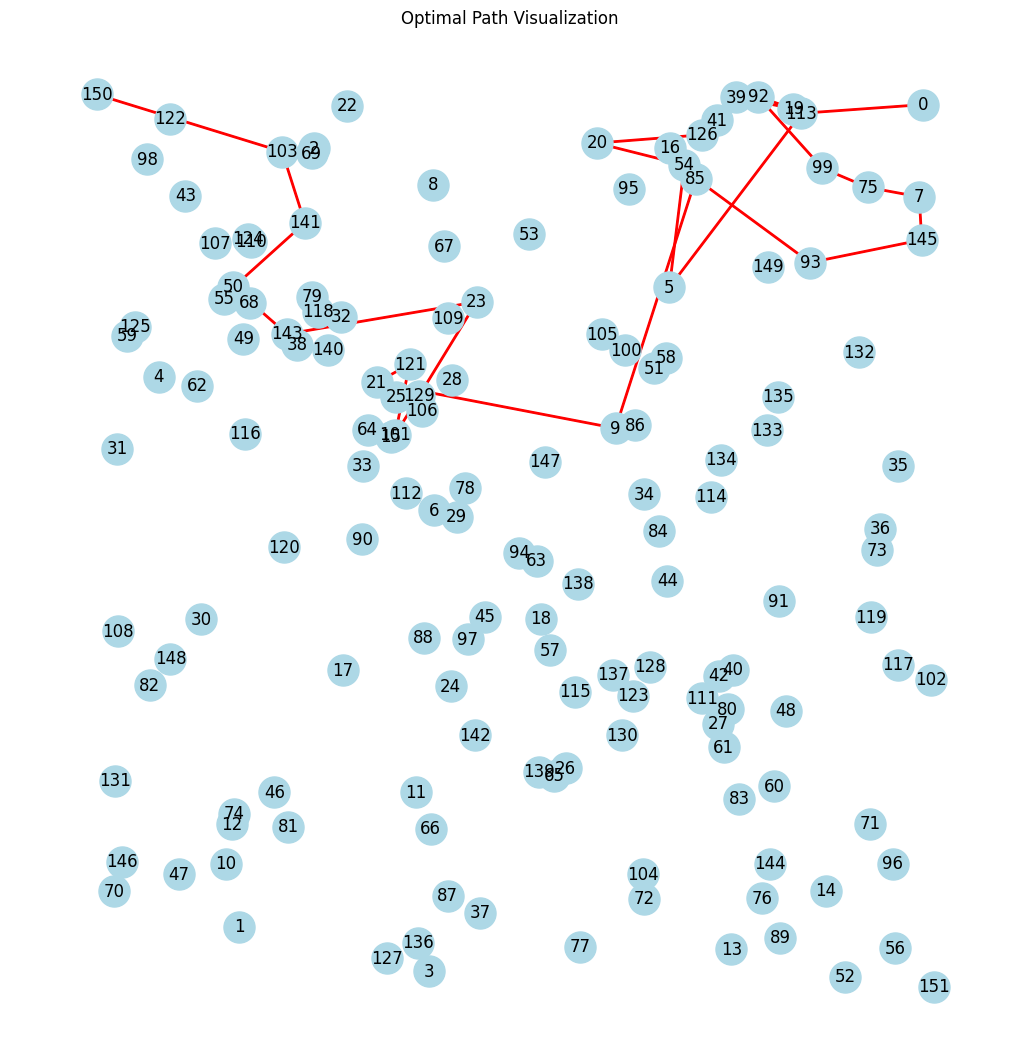

In [82]:
#Visualizing the path for example case
visualize_optimal_path(best_path, coordinates)

In [83]:
all_results_aco = {}
for node in range(len(distance_matrix) - len(base_station_indices)):
    results, _ = ant_colony_optimization_optimized(node, distance_matrix, rate_matrix, base_station_indices)
    all_results_aco[f"Node-{node}"] = results

In [84]:
# Save the results to a JSON file
output_file = "aco_optimized_results.json"
with open(output_file, "w") as f:
    json.dump(all_results_aco, f, indent=4)

In [85]:
print(f"All Optimized ACO results have been saved to {output_file}")

All Optimized ACO results have been saved to aco_optimized_results.json



# Genetic Algorithm (GA):

Genetic algorithms (GAs) are evolutionary optimization approaches based on natural selection principles (Holland, 1975). GAs are well-suited for routing path optimization in wireless sensor networks because they may explore vast, discrete solution spaces with numerous objectives, such as minimizing latency and maximizing transmission rates (Mitchell, 1998).


 GA is suitable for this problem because:
 - It can handle a large solution space with multiple objectives (rate and latency).
 - GA avoids local minima by maintaining a diverse population of potential solutions.
 - GA performs well when there are no deterministic shortcuts for an optimal path.

## Step 1: Fitness Function:
The fitness function evaluates pathways using two distinct objectives:

* **Latency:** To compute overall latency, use the formula L(r)=n⋅LATENCY_PER_LINK, where 𝑛 is the number of hops in the path and LATENCY_PER_LINK is a preset constant. This guarantees that pathways with fewer hops are preferred for lower delays.
* **Transmission Rate:** The transmission rate is defined as the lowest transmission rate along the path, indicating the weakest link in terms of bandwidth. By favoring pathways with greater minimum transmission rates, the algorithm ensures that data transfers are dependable.





This multi-objective approach aligns with standard practices in optimization, where trade-offs between delay and throughput are critical for routing problems (Deb, 2001).

In [ ]:
POPULATION_SIZE = 50
MUTATION_RATE = 0.1
GENERATIONS = 100

In [ ]:
def is_valid_path(path):
    return all(rate_matrix[path[i], path[i + 1]] > 0 for i in range(len(path) - 1))

In [ ]:
def fitness(path):
    if len(path) < 2 or not is_valid_path(path):
        return float('inf'), float('inf')  # Invalid path

    latency = len(path) * LATENCY_PER_LINK
    transmission_rate = min(rate_matrix[path[i], path[i + 1]] for i in range(len(path) - 1))
    return latency, -transmission_rate  # Maximize rate, minimize latency

\assastart noode = 0
start_node = 0
## Step 2: Population Initialization
The population initialization stage creates an initial collection of candidate solutions (paths) for the GA. Each path begins at the source node and leads to one of the base stations.

The use of random neighbor selection ensures diversity in the population, preventing premature convergence to suboptimal solutions (Holland, 1975).

This diversity in the population is critical for the GA to explore a wide range of potential solutions effectively (Goldberg, 1989).


In [ ]:
def initialize_population(start_node, base_stations, population_size=POPULATION_SIZE):
    population = []

    for _ in range(population_size):
        path = [start_node]
        current_node = start_node

        while current_node not in base_stations:
            neighbors = [j for j in range(num_nodes) if rate_matrix[current_node, j] > 0 and j not in path]

            if not neighbors:
                break

            next_node = random.choice(neighbors)
            path.append(next_node)
            current_node = next_node

        if current_node in base_stations:
            population.append(path)

    return population


## Step 3: Selection
The fittest solutions are chosen to be passed on to the next generation. This ensures the retention of high-quality traits while discarding suboptimal solutions (Mitchell, 1998).


In [ ]:
def selection(population):
    fitness_scores = [(fitness(path), path) for path in population]
    fitness_scores.sort(key=lambda x: (x[0][0], x[0][1]))  # Sort by latency, then rate
    return [x[1] for x in fitness_scores[:len(fitness_scores) // 2]]

## Step 4: Crossover
Selected solutions (parents) are merged to form offspring paths. By mixing segments of paths, crossover introduces diversity and allows exploration of new regions of the solution space (Back, 1996).

In [ ]:
def crossover(parent1, parent2):
    split_point = random.randint(1, min(len(parent1), len(parent2)) - 1)
    child = parent1[:split_point] + [node for node in parent2 if node not in parent1[:split_point]]
    return child

Crossover introduces new combinations of nodes from parents, which can lead to novel solutions (Goldberg, 1989).
The single-point crossover ensures simplicity while maintaining structural integrity of the path.

## Step 5: Mutation
To maintain genetic diversity, a small fraction of offspring paths change at random.This prevents premature convergence and ensures the algorithm does not stagnate in local optima (Whitley, 1994).

In [ ]:
def mutate(path, mutation_rate=0.1):
    if random.random() < mutation_rate:
        idx = random.randint(0, len(path) - 2)
        neighbors = [j for j in range(num_nodes) if rate_matrix[path[idx], j] > 0 and j not in path]
        if neighbors:
            path[idx + 1] = random.choice(neighbors)
    return path

##Genetic Algorithm Execution


The process is repeated for a set number of generations (100 in this project). The final solution is chosen based on the best-performing path, as determined by the fitness function.


In [ ]:
def genetic_algorithm(start_node, base_stations, generations=GENERATIONS, population_size=POPULATION_SIZE):
    population = initialize_population(start_node, base_stations, population_size)
    best_path = None
    best_fitness = (float('inf'), float('-inf'))

    for generation in range(generations):
        population = selection(population)

        offspring = []
        while len(offspring) < population_size:
            parent1, parent2 = random.sample(population, 2)
            child = crossover(parent1, parent2)
            offspring.append(mutate(child))

        population = offspring

        for path in population:
            current_fitness = fitness(path)
            if current_fitness < best_fitness:
                best_fitness = current_fitness
                best_path = path

        print(f"Generation {generation + 1}/{generations}: Best Fitness = {best_fitness}")

    return best_path, best_fitness


In [89]:
start_node = 0
best_path, best_fitness = genetic_algorithm(start_node, base_stations, generations=GENERATIONS, population_size=POPULATION_SIZE)

Generation 1/100: Best Fitness = (1170, -1)
Generation 2/100: Best Fitness = (1170, -1)
Generation 3/100: Best Fitness = (1170, -1)
Generation 4/100: Best Fitness = (1170, -1)
Generation 5/100: Best Fitness = (1170, -1)
Generation 6/100: Best Fitness = (1170, -1)
Generation 7/100: Best Fitness = (1170, -1)
Generation 8/100: Best Fitness = (1170, -1)
Generation 9/100: Best Fitness = (1170, -1)
Generation 10/100: Best Fitness = (1170, -1)
Generation 11/100: Best Fitness = (1170, -1)
Generation 12/100: Best Fitness = (1170, -1)
Generation 13/100: Best Fitness = (1170, -1)
Generation 14/100: Best Fitness = (1170, -1)
Generation 15/100: Best Fitness = (1170, -1)
Generation 16/100: Best Fitness = (1170, -1)
Generation 17/100: Best Fitness = (1170, -1)
Generation 18/100: Best Fitness = (1170, -1)
Generation 19/100: Best Fitness = (1170, -1)
Generation 20/100: Best Fitness = (1170, -1)
Generation 21/100: Best Fitness = (1170, -1)
Generation 22/100: Best Fitness = (1170, -1)
Generation 23/100: 

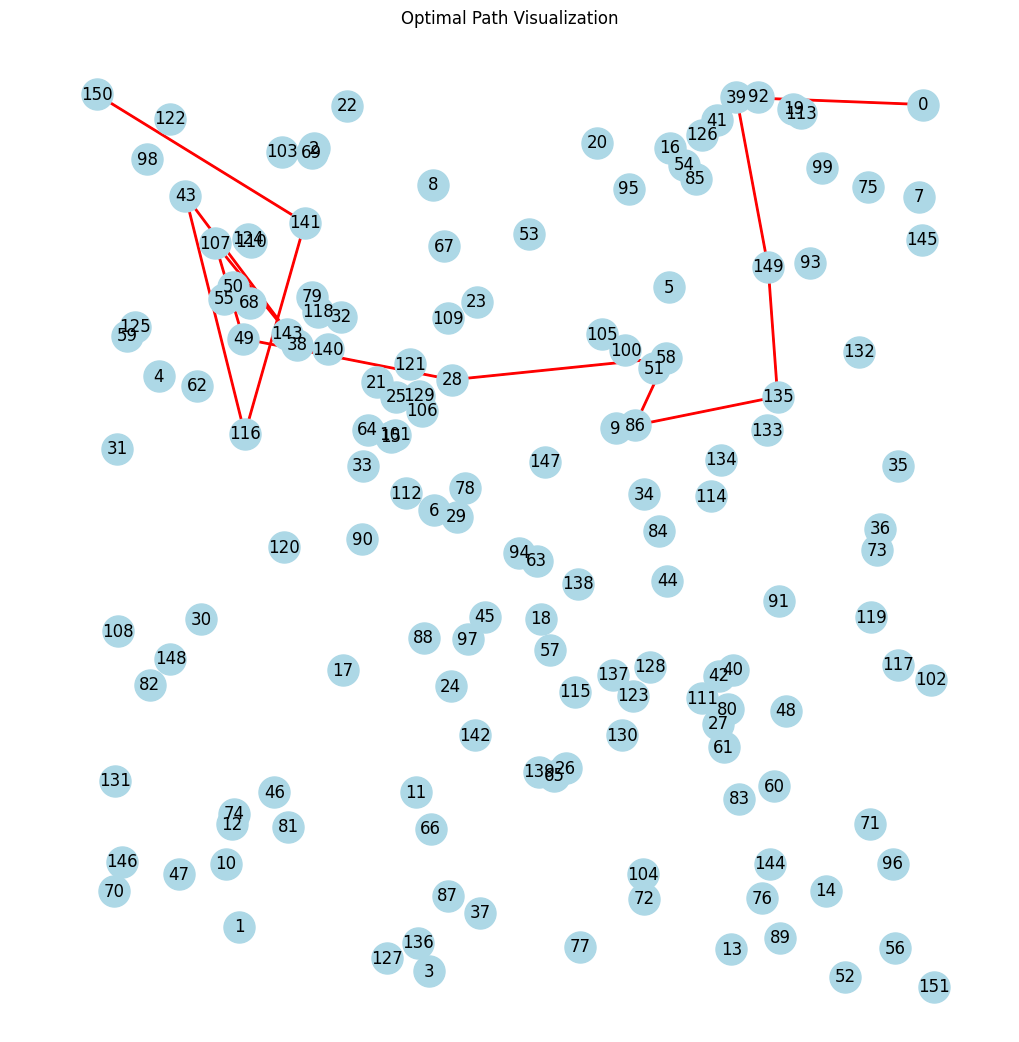

In [69]:
# Visualize the optimal path
visualize_optimal_path(best_path, coordinates)

Generate and Print the Final Solution


In [73]:
def genetic_algorithm_for_all_nodes(base_stations, generations, population_size):
    all_solutions = {}

    for start_node in range(num_nodes - len(base_stations)):
        print(f"Running GA for Node-{start_node + 1}...")

        # Run GA for the current node
        best_path, best_fitness = genetic_algorithm(
            start_node=start_node,
            base_stations=base_stations,
            generations=generations,
            population_size=population_size
        )

        if best_path:
            # Format the solution for the current node
            routing_path = []
            for i in range(len(best_path) - 1):
                current_node = best_path[i]
                next_node = best_path[i + 1]
                transmission_rate = rate_matrix[current_node, next_node]
                routing_path.append(f"(Node-{next_node + 1}, {transmission_rate} Mbps)")

            end_to_end_rate = min(rate_matrix[best_path[i], best_path[i + 1]] for i in range(len(best_path) - 1))
            solution = {
                "Source node": f"Node-{start_node + 1}",
                "Routing path": ", ".join(routing_path),
                "End-to-end transmission rate": f"{end_to_end_rate} Mbps"
            }
        else:
            solution = f"No valid path from Node-{start_node + 1} to any base station"

        all_solutions[f"Node-{start_node + 1}"] = solution

    return all_solutions

In [74]:
# Save all GA solutions to JSON
def save_all_genetic_algorithm_results(all_solutions, filename="ga_results.json"):
    with open(filename, "w") as f:
        json.dump(all_solutions, f, indent=4)
    print(f"All GA solutions saved to '{filename}'")

In [88]:
# Run the GA for all nodes
all_solutions = genetic_algorithm_for_all_nodes(base_stations, generations=GENERATIONS, population_size=POPULATION_SIZE)
save_all_genetic_algorithm_results(all_solutions)

Streaming output truncated to the last 5000 lines.
Generation 51/100: Best Fitness = (240, -1)
Generation 52/100: Best Fitness = (240, -1)
Generation 53/100: Best Fitness = (240, -1)
Generation 54/100: Best Fitness = (240, -1)
Generation 55/100: Best Fitness = (240, -1)
Generation 56/100: Best Fitness = (240, -1)
Generation 57/100: Best Fitness = (240, -1)
Generation 58/100: Best Fitness = (240, -1)
Generation 59/100: Best Fitness = (240, -1)
Generation 60/100: Best Fitness = (240, -1)
Generation 61/100: Best Fitness = (240, -1)
Generation 62/100: Best Fitness = (240, -1)
Generation 63/100: Best Fitness = (240, -1)
Generation 64/100: Best Fitness = (240, -1)
Generation 65/100: Best Fitness = (240, -1)
Generation 66/100: Best Fitness = (240, -1)
Generation 67/100: Best Fitness = (240, -1)
Generation 68/100: Best Fitness = (240, -1)
Generation 69/100: Best Fitness = (240, -1)
Generation 70/100: Best Fitness = (240, -1)
Generation 71/100: Best Fitness = (240, -1)
Generation 72/100: Best F

In [77]:
with open("ga_results.json", "r") as file:
    routing_paths = json.load(file)

print(json.dumps(routing_paths, indent=4))

{
    "Node-1": {
        "Source node": "Node-1",
        "Routing path": "(Node-146, 3 Mbps), (Node-76, 5 Mbps), (Node-150, 4 Mbps), (Node-36, 1 Mbps), (Node-118, 2 Mbps), (Node-97, 2 Mbps), (Node-57, 5 Mbps), (Node-84, 1 Mbps), (Node-53, 2 Mbps), (Node-152, 4 Mbps)",
        "End-to-end transmission rate": "1 Mbps"
    },
    "Node-2": {
        "Source node": "Node-2",
        "Routing path": "(Node-75, 4 Mbps), (Node-47, 5 Mbps), (Node-109, 1 Mbps), (Node-132, 3 Mbps), (Node-83, 4 Mbps), (Node-71, 2 Mbps), (Node-149, 1 Mbps), (Node-121, 3 Mbps), (Node-69, 1 Mbps), (Node-23, 1 Mbps), (Node-104, 5 Mbps), (Node-151, 2 Mbps)",
        "End-to-end transmission rate": "1 Mbps"
    },
    "Node-3": {
        "Source node": "Node-3",
        "Routing path": "(Node-70, 7 Mbps)",
        "End-to-end transmission rate": "7 Mbps"
    },
    "Node-4": {
        "Source node": "Node-4",
        "Routing path": "(Node-140, 1 Mbps), (Node-78, 2 Mbps), (Node-77, 2 Mbps), (Node-14, 5 Mbps), (Node-9

**Advantages of GA for Routing Optimization**

* **Exploring Large Solution Spaces:** GAs effectively explore huge, complex solution spaces, making them suited for situations that deterministic approaches such as Dijkstra's algorithm cannot solve (Glover and Kochenberger, 2003).

* **Flexibility:** The algorithm balances numerous objectives, such as latency minimization and transmission rate maximization, by adjusting weights in the fitness function (Deb 2001).


* **Adaptability:** The iterative structure of GAs allows for dynamic adjustments to solutions, ensuring robustness in scenarios with dynamic constraints and network conditions (Holland, 1975).




**Limitations of GA:**

* **Computational overhead:** GAs involve iterative evaluation of populations over numerous generations, making them more computationally intensive than deterministic techniques.
* **Risk of premature convergence:** Without proper diversity mechanisms, GAs may converge on mediocre solutions early on, especially in complex or rough fitness landscapes (Whitley, 1994).




#Evaluation of results

The purpose of this study was to find the best routing paths in a wireless sensor network (WSN) from a source node to a base station. The evaluation sought to balance two major metrics:

* **Minimizing Latency:** The time it takes for the algorithm to compute the solution.
* **Maximizing Transmission Rates:** Evaluated using the end-to-end transmission rate (the lowest rate along the path) and the average transmission rate.

We will now take into consideration our previous results and evaluate all the algorithms based on metrics:
* Algorithm execution time (in seconds)
* End-to-End transmission ate for one node (in Mbps)
* Average transmission rate for all nodes (in Mbps)
* Adaptability

But first, we'll calculate the average transmission rate in below.

In [86]:
def calculate_average_rate(file_path, skip_last_entries=0):
    """
    Calculate the average end-to-end transmission rate from a JSON file.

    Args:
        file_path (str): Path to the JSON file.
        skip_last_entries (int): Number of entries to skip from the end.

    Returns:
        float: The average transmission rate.
    """
    with open(file_path, 'r') as file:
        data = json.load(file)

    # Extract rates while skipping the specified number of last entries
    rates = []
    data_items = list(data.items())
    for node, details in data_items[:-skip_last_entries if skip_last_entries > 0 else None]:
        rate_str = details["End-to-end transmission rate"]
        rate = float(rate_str.split(" ")[0])  # Convert rate string to float
        rates.append(rate)

    return sum(rates) / len(rates) if rates else 0

# List of file paths and corresponding labels
file_configs = [
    ('dijkstra_results.json', "Dijkstra's solution", 2),  # Skip last 2 entries
    ('aco_results.json', "ACO solution", 0),
    ('aco_optimized_results.json', "ACO Optimized solution", 0),
    ('ga_results.json', "GA solution", 0),
]

In [87]:
# Calculate and print average rates for each solution
for file_path, label, skip_last_entries in file_configs:
    average_rate = calculate_average_rate(file_path, skip_last_entries)
    print(f"Average Total Rate of Transmission for {label}: {average_rate:.2f} Mbps")

Average Total Rate of Transmission for Dijkstra's solution: 1.47 Mbps
Average Total Rate of Transmission for ACO solution: 1.39 Mbps
Average Total Rate of Transmission for ACO Optimized solution: 1.31 Mbps
Average Total Rate of Transmission for GA solution: 2.05 Mbps


**End-to-End Transmission Rate for a Single Node**

For the start node (node 0), the end-to-end transmission rates remained consistent at 1 Mbps across all algorithms, ensuring minimal performance disparities for this metric.


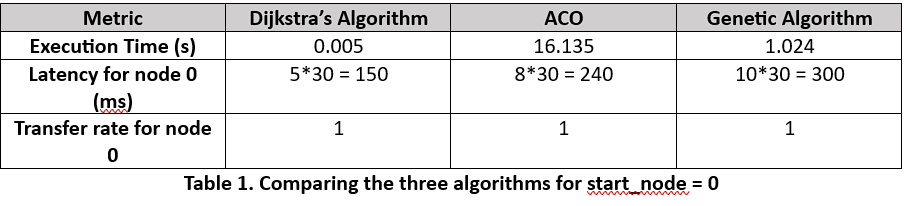

**Algorithm Execution Time**

Execution time, a measure of computational efficiency, varies significantly across algorithms:

* Dijkstra's Algorithm demonstrated the fastest execution time at 2.307 seconds, highlighting its computational simplicity.

* ACO exhibited the highest execution time at 2457.451 seconds, primarily due to its iterative, probabilistic approach.

* Optimized ACO improved significantly with an execution time of 1151.921 seconds, achieving faster convergence while retaining adaptability.

* GA struck a balance between exploration and exploitation, completing in 102.541 seconds, showcasing moderate computational demand.

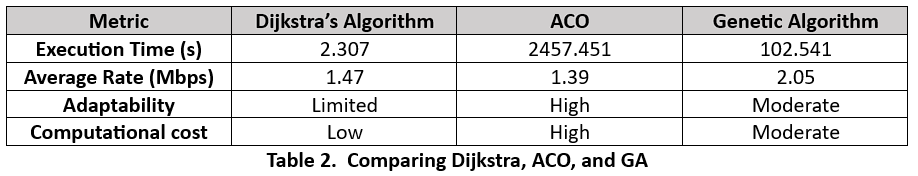

**Average Transmission Rate**

The average transmission rate for all nodes differed across algorithms, reflecting their routing efficiency:

* Dijkstra’s Algorithm achieved an average transmission rate of 1.47 Mbps, emphasizing its preference for high-speed connections.

* ACO and Optimized ACO yielded average rates of 1.39 Mbps and 1.31 Mbps, respectively.

* The slight reduction in the optimized version reflects its trade-off between computational efficiency and transmission performance.

* GA outperformed the others with an average transmission rate of 2.05 Mbps, suggesting its ability to identify efficient routing paths.

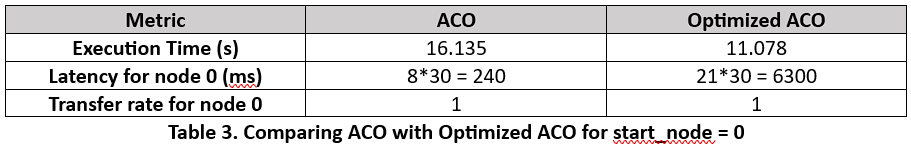

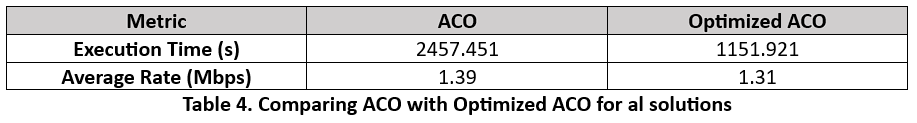

**Adaptability**

Adaptability is critical in dynamic networks where conditions vary:

* Dijkstra’s Algorithm offers limited adaptability due to its deterministic nature and static path computation.

* ACO excels in adaptability, exploring multiple routing paths probabilistically. However, its execution time limits real-time applications.

* Optimized ACO balances adaptability and computational efficiency, making it suitable for scenarios requiring moderate adaptability.

* GA demonstrates moderate adaptability, efficiently balancing exploration and exploitation during path optimization.

**Computational Cost**

Computational cost correlates directly with execution time:

* Dijkstra’s Algorithm has the lowest computational cost, making it ideal for time-sensitive, resource-constrained applications.

* ACO incurs the highest computational cost, while Optimized ACO reduces this significantly without sacrificing much adaptability.

* GA offers a moderate computational cost, making it viable for multi-objective optimization tasks.

**Dijkstra’s Algorithm**

Dijkstra’s Algorithm is highly effective for latency-critical scenarios due to its low computational cost and fast execution time. However, its deterministic nature and lack of adaptability make it less suitable for dynamic or large-scale WSNs.

**Ant colony optimization (ACO)**

ACO’s adaptability and exploration capabilities make it a strong candidate for dynamic networks, though its high computational time of 2457.451 seconds limits its application in time-sensitive tasks.

**Optimized ACO**
Optimized ACO addresses this issue by halving the execution time from 2457.451 seconds to 1151.921 seconds, making it a more practical solution for real-world scenarios. However, the slight reduction in average transmission rate from 1.39 Mbps to 1.31 Mbps indicates a trade-off between performance metrics.

**Genetic Algorithm (GA)**

GA provides a balanced approach, combining moderate execution time of 102.541 seconds, adaptability, and superior average transmission rates of 2.05 Mbps. Its computational efficiency and ability to handle multi-objective optimization make it an attractive choice for varied network environments.


# Limitations and Future Scope

1. **Processing Requirements**

Both Ant Colony Optimization (ACO) and the Genetic Algorithm (GA) exhibited significantly higher processing requirements compared to Dijkstra’s Algorithm. Despite parameter adjustments, such as reducing iterations and the number of ants, ACO’s execution time remained notably high, making it unsuitable for time-critical applications.

2. **Scalability**

Dijkstra’s Algorithm performed well on smaller networks but struggled to scale efficiently due to its reliance on global network information. In contrast, ACO and GA scaled better with increasing network size, although their returns on solution quality and convergence time diminished as the network size grew.

3. **Probabilistic Nature**

The probabilistic nature of ACO and GA occasionally resulted in suboptimal paths. These less reliable routes were particularly unsuitable for networks with strict latency and transmission rate requirements, limiting their applicability in such scenarios.

4. **Static Network Conditions**

This study was conducted under static network settings, assuming constant link rates and latencies. This simplification does not accurately reflect real-world WSNs, where dynamic factors such as fluctuating link quality, node failures, and interference significantly affect performance. Moreover, the study did not consider energy consumption, interference, or node mobility, limiting its relevance to real-world applications.

**Future Scope**

Future research should explore hybrid optimization techniques that integrate the computational efficiency of Dijkstra’s Algorithm with the adaptability of ACO and GA. Key areas of focus should include:

* **Energy Efficiency:** Designing energy-aware routing protocols to prolong network lifespan.

* **Dynamic Adaptability:** Accounting for real-world network dynamics, such as node mobility, interference, and varying link quality.

* **Multi-Objective Optimization:** Developing algorithms that optimize latency, transmission rates, and energy consumption simultaneously.

By addressing these limitations, future studies can create robust routing algorithms tailored to the complex and dynamic nature of real-world WSNs

#Conclusion

Conclusion

Each algorithm offers distinct strengths and weaknesses based on the network’s requirements:

* For static networks requiring minimal latency, Dijkstra’s Algorithm is optimal.

* For highly dynamic and adaptable networks, ACO or Optimized ACO are recommended, with the latter being computationally more efficient.

* For scenarios balancing multiple objectives, GA is the most versatile choice.

Future work could explore hybrid approaches combining the computational efficiency of Dijkstra’s Algorithm with the adaptability of ACO or GA to address broader WSN challenges.

# References
* Akyildiz, I.F., Su, W., Sankarasubramaniam, Y. and Cayirci, E. (2002) ‘A survey on sensor networks’, IEEE Communications Magazine, 40(8), pp. 102–114.

* Back, T. (1996) Evolutionary Algorithms in Theory and Practice: Evolution Strategies, Evolutionary Programming, Genetic Algorithms. Oxford: Oxford University Press.

* Blum, C. (2016) 'Ant Colony Optimization: A Component-Wise Overview', in Handbook of Heuristics. Springer.

* Cormen, T.H., Leiserson, C.E., Rivest, R.L. and Stein, C. (2009) Introduction to Algorithms. 3rd edn. Cambridge, MA: MIT Press.

* Deb, K. (2001) Multi-Objective Optimization Using Evolutionary Algorithms. New York: Wiley.

* Deza, M.M. and Deza, E. (2014) Encyclopedia of Distances. 3rd edn. Berlin: Springer.

* Dijkstra, E.W. (1959) ‘A note on two problems in connexion with graphs’, Numerische Mathematik, 1(1), pp. 269–271.

* Dorigo, M. and Stützle, T. (2004) Ant Colony Optimization. Cambridge, MA: MIT Press.

* Dorigo, M., Birattari, M. and Stützle, T., 2006. Ant colony optimization: Artificial ants as a computational intelligence technique. IEEE Computational Intelligence Magazine, 1(4), pp.28-39.

* Glover, F. and Kochenberger, G. (2006) Handbook of Metaheuristics. Springer.

* Goldberg, D.E. (1989) Genetic Algorithms in Search, Optimization and Machine Learning. Reading, MA: Addison-Wesley

* Gutjahr, W.J., 2000. A graph-based ant system and its convergence. Future Generation Computer Systems, 16(9), pp.873-888.

* Harris, C.R., Millman, K.J., van der Walt, S.J., et al. (2020) ‘Array programming with NumPy’, Nature, 585(7825), pp. 357–362.

* Holland, J.H. (1975) Adaptation in Natural and Artificial Systems. Ann Arbor, MI: University of Michigan Press.

* Li, X. and Liu, Z. (2012) 'Ant colony optimization for wireless sensor networks routing', Proceedings of the 2012 IEEE International Conference on Computer Science and Automation Engineering, Zhangjiajie, China, 25-27 May, pp. 100-104.

* Mitchell, M. (1998) An Introduction to Genetic Algorithms. Cambridge, MA: MIT Press.

* Rajasekhar, A., Reddy, A.R. and Reddy, V.V., 2020. Parallel implementation of ant colony optimization algorithm using GPU for combinatorial optimization problems. Cluster Computing, 23(1), pp.265-274.

* Stützle, T. and Hoos, H.H., 2000. MAX–MIN ant system. Future Generation Computer Systems, 16(8), pp.889-914.

* Socha, K. and Dorigo, M. (2008) ‘Ant colony optimization for continuous domains’, European Journal of Operational Research, 185(3), pp. 1155–1173.

* Tilak, S., Abu-Ghazaleh, N.B. and Heinzelman, W. (2002) ‘A taxonomy of wireless micro-sensor network models’, ACM SIGMOBILE Mobile Computing and Communications Review, 6(2), pp. 28–36.

* Van Rossum, G. and Drake, F.L. (2009) Python 3 Reference Manual. Scotts Valley, CA: CreateSpace.

* Wahyuningsih, D. and Syahreza, E., 2018. Shortest Path Search Futsal Field Location With Dijkstra Algorithm. IJCCS (Indonesian Journal of Computing and Cybernetics Systems), 12 (2), 161.

* Whitley, D. (1994) ‘A genetic algorithm tutorial’, Statistics and Computing, 4(2), pp. 65–85.